# Composición institucional del gasto público en la UE-27
**Pablo Sánchez González · Universidad Complutense de Madrid · Economía Pública**

## Resumen
Entre 2017–2019 y 2022–2024, la participación media de los gobiernos centrales en el gasto aumenta **1,148 pp**, con subidas en **21 de 27 países**. El test de medias conserva un valor p ajustado por Holm de **0,0359**. Las seis comparaciones pre/post examinadas dan aumentos de esa participación entre **0,602 y 1,404 pp**.

Se mide composición de la suma del gasto subsectorial, no gasto final consolidado, autonomía política ni efecto causal de la COVID-19. La unidad del contraste es el país. Todas las celdas pueden ejecutarse de arriba abajo; la instantánea original no se descarga ni se sobrescribe.

## 1. Pregunta económica y método
¿Cambió la composición del gasto entre los distintos niveles de gobierno después de los primeros años de la pandemia? La capacidad central de estabilización y financiación puede elevar su gasto relativo, incluso mediante transferencias que sostienen servicios territoriales. El resultado no equivale por sí solo a reasignación de competencias. Las fuentes y las decisiones de medición se desarrollan en [cuestiones metodológicas](02_cuestiones_metodologicas.ipynb).

### Supuestos principales
Misma población UE-27 en todos los años; igual peso por país y año; ceros únicamente en subsectores documentados como no aplicables; test t exploratorio de diferencias nacionales independientes. La comparación temporal no identifica un contrafactual.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src/analysis.py").exists():
    ROOT = ROOT.parent
assert (ROOT / "src/analysis.py").exists(), "Ejecutar desde la raíz o notebooks/"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
from IPython.display import display, Image
from src.prepare_data import decode_snapshot, prepare, SHARES, STATE_COUNTRIES
from src.analysis import (
    LABELS,
    NAMES,
    changes as calculate_changes,
    inference,
    period_mean,
    temporal_sensitivity,
    leave_one_out,
    grouped_change,
)

raw, snapshot = decode_snapshot()
wide, audit = prepare(raw)
pd.set_option("display.max_columns", 12)

# Regenerar las figuras si se ejecuta este cuaderno por separado.
if not (ROOT / ".resultados/figuras/serie_anual.png").exists():
    from src.prepare_data import main as preparar
    from src.build_outputs import main as generar

    preparar()
    generar()

from scipy import stats
from statsmodels.stats.multitest import multipletests

share_columns = SHARES.copy()

## 2. Datos y controles
Eurostat `gov_10a_exp`, frecuencia anual, `TE`, `TOTAL`, 2015–2024. La unidad principal es porcentaje del PIB. El PIB se cancela en las cuotas; se comprueba el efecto del redondeo con millones de euros. Preservamos las marcas de calidad y distinguimos valor publicado de cero estructural.

In [2]:
print("Actualización de la instantánea:", snapshot["updated"])
print("Países:", wide["geo"].nunique(), "| Filas:", len(wide))
display(audit.groupby(["sector", "treatment"]).size().unstack(fill_value=0))
assert len(wide) == 270
assert wide.groupby("geo").size().eq(10).all()
np.testing.assert_allclose(wide[SHARES].sum(axis=1), 100)

Actualización de la instantánea: 2026-09-16T23:00:00+0200
Países: 27 | Filas: 270


treatment,cero_estructural_documentado,valor_publicado
sector,,
S13,0,270
S1311,0,270
S1312,230,40
S1313,0,270
S1314,10,260


## 3. Cuotas y diferencias emparejadas
La cuota es $s_{ikt}=100 E_{ikt}/\sum_j E_{ijt}$. El denominador incluye transferencias entre subsectores: no es S.13 consolidado. La diferencia de medias de tres años mantiene emparejado cada país. El índice $R_i=\frac12\sum_k|\Delta_{ik}|$ mide distancia composicional, no euros transferidos.

El cálculo se desarrolla aquí paso a paso. Las funciones de `src/analysis.py` repiten estas operaciones para generar el informe y para comparar otras ventanas. Las comprobaciones de igualdad aseguran que ambas formas de calcularlo coinciden.

In [3]:
# Cada media resume tres años del mismo país.
period_means = (
    wide[wide["period"].isin(["pre", "post"])]
    .groupby(["geo", "period"])[share_columns]
    .mean()
    .reset_index()
)

pre = period_means[period_means["period"] == "pre"].set_index("geo")[share_columns]
post = period_means[period_means["period"] == "post"].set_index("geo")[share_columns]

# Un valor positivo indica que el subsector gana participación.
changes = post - pre
changes["reallocation_index"] = changes[share_columns].abs().sum(axis=1) / 2

# La versión del informe exige años completos. Comprobamos que coincide.
pd.testing.assert_frame_equal(changes, calculate_changes(wide), check_exact=True)

summary = pd.DataFrame(
    {
        "pre": pre.mean(),
        "post": post.mean(),
        "cambio_pp": changes[share_columns].mean(),
    }
)
display(summary.rename(index=LABELS).round(3))
print("Países con aumento central:", int((changes["share_central"] > 0).sum()))
print("Índice medio:", round(changes["reallocation_index"].mean(), 3))

,pre,post,cambio_pp
Central,54.433,55.582,1.148
Regional (S.1312),3.430,3.406,-0.024
Local,17.790,17.334,-0.456
Seguridad social,24.347,23.679,-0.668


Países con aumento central: 21
Índice medio: 2.057


## 4. Trayectoria anual
La serie anual complementa los periodos. La cuota central desciende antes de 2020 y aumenta en ese año: no es correcto afirmar ausencia de tendencia previa. Cada panel usa una escala vertical propia; comparar pendientes exige leer los ejes. La estabilidad de la media central entre 2020–2021 y 2022–2024 tampoco implica inmovilidad de todos los países.

,share_central,share_state,share_local,share_social_security
time,,,,
2015,55.383,3.417,17.538,23.663
2016,55.008,3.420,17.254,24.319
2017,54.549,3.409,17.598,24.445
2018,54.646,3.445,17.770,24.139
2019,54.106,3.435,18.001,24.458
2020,55.565,3.354,16.722,24.358
2021,55.602,3.386,16.920,24.092
2022,55.803,3.387,17.189,23.621
2023,55.755,3.417,17.455,23.373


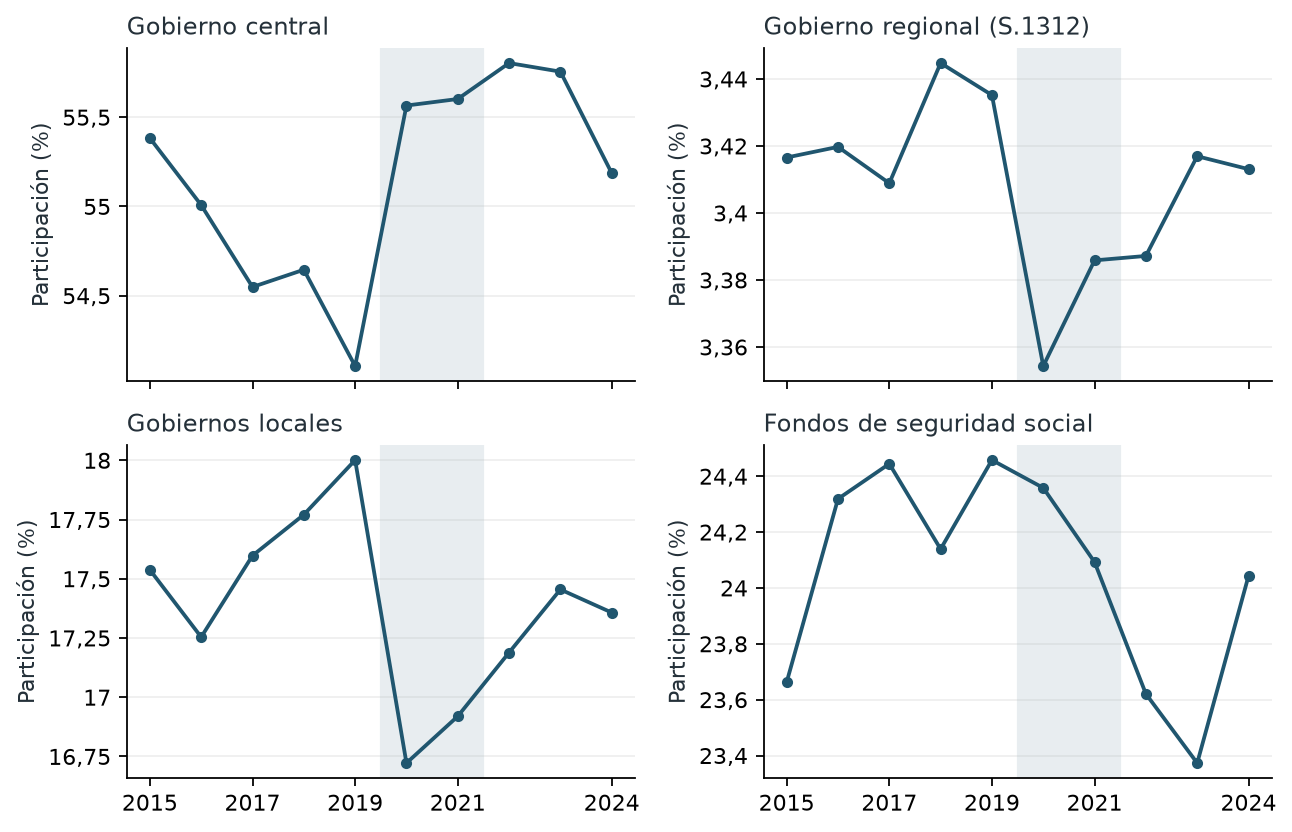

In [4]:
trend = wide.groupby("time")[SHARES].mean()
display(trend.round(3))
display(Image(filename=str(ROOT / ".resultados/figuras/serie_anual.png")))

## 5. Inferencia exploratoria
Referencia principal: test t bilateral de la media de las diferencias, con Holm sobre tres contrastes (central, local y seguridad social). Wilcoxon es complementario, con su propia familia de tres pruebas. Holm trata multiplicidad, no dependencia composicional ni correlación entre países. S.1312 se describe, pero no se contrasta con 23 ceros estructurales.

Los 27 países agotan la población de interés. Los IC y valores p requieren un modelo hipotético de variación entre países; no representan error de muestreo de la UE. Wilcoxon tampoco contrasta exactamente la misma hipótesis que el test de medias. Sus resultados dependen de simetría/independencia; Malta aporta una diferencia nula en seguridad social.

In [5]:
variables = ["share_central", "share_local", "share_social_security"]
results = []

# Hay una diferencia por país: cada prueba utiliza 27 observaciones.
for variable in variables:
    x = changes[variable]
    mean_change = x.mean()
    standard_error = stats.sem(x)

    ci_low, ci_high = stats.t.interval(
        0.95,
        df=len(x) - 1,
        loc=mean_change,
        scale=standard_error,
    )
    t_test = stats.ttest_1samp(x, popmean=0)
    wilcoxon = stats.wilcoxon(
        x, zero_method="wilcox", alternative="two-sided", method="auto"
    )
    results.append(
        {
            "sector": variable,
            "n": len(x),
            "mean_change": mean_change,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_ttest": t_test.pvalue,
            "p_wilcoxon": wilcoxon.pvalue,
        }
    )

results_df = pd.DataFrame(results)

### Ajuste por comparaciones múltiples
Se corrigen los valores p porque se realizan tres contrastes por procedimiento. Los intervalos anteriores siguen siendo individuales.

,sector,n,mean_change,ci_low,ci_high,p_ttest,p_wilcoxon,p_ttest_holm,p_wilcoxon_holm
0,share_central,27,1.1483,0.2748,2.0219,0.0120,0.0019,0.0359,0.0056
1,share_local,27,-0.4561,-0.8842,-0.0280,0.0377,0.0385,0.0753,0.0385
2,share_social_security,27,-0.6683,-1.3735,0.0369,0.0623,0.0026,0.0753,0.0056


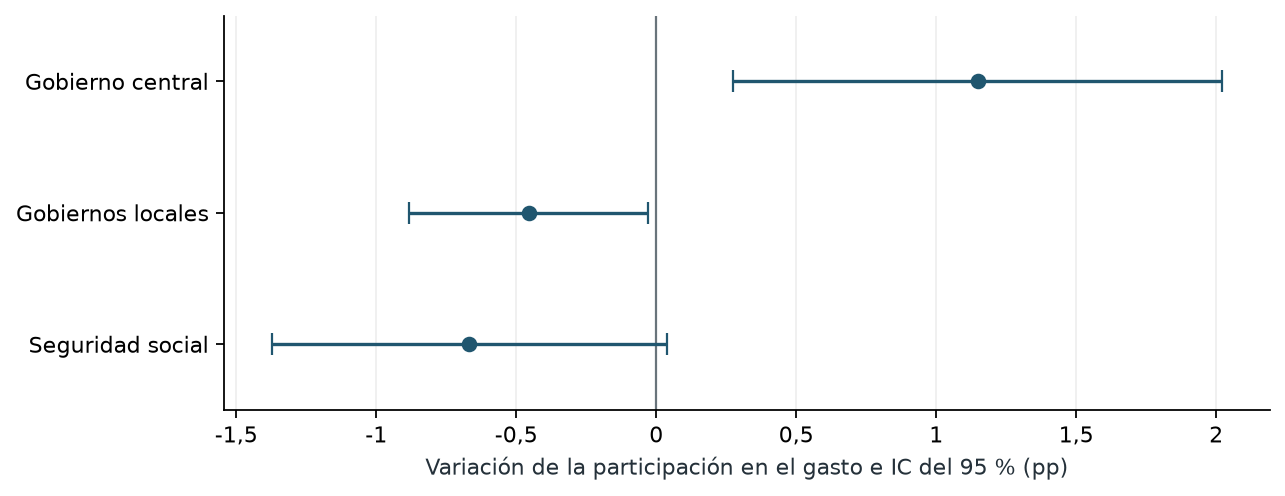

In [6]:
# Holm se aplica por separado a las tres pruebas de cada procedimiento.
results_df["p_ttest_holm"] = multipletests(results_df["p_ttest"], method="holm")[1]
results_df["p_wilcoxon_holm"] = multipletests(results_df["p_wilcoxon"], method="holm")[
    1
]

pd.testing.assert_frame_equal(results_df, inference(changes), check_exact=True)
display(results_df.round(4))
display(Image(filename=str(ROOT / ".resultados/figuras/intervalos.png")))

Solo central mantiene p < 0,05 en la familia principal. Local y seguridad social tienen p ajustado 0,0753. Los intervalos de la figura son marginales y no se ajustan con Holm; por eso el IC local puede excluir cero y su p ajustado no ser significativo. No se escoge a posteriori el método más favorable.

## 6. Heterogeneidad y frontera institucional
Chipre reduce el peso central y aumenta seguridad social; al agrupar ambos componentes su cambio es pequeño y positivo. No atribuimos esa trayectoria a una reforma no investigada. La suma central+SS reduce la sensibilidad al reparto interno entre esos dos subsectores, pero no consolida sus transferencias ni mide autonomía. España muestra un aumento central de 1,567 pp.

,share_central,share_state,share_local,share_social_security,reallocation_index,central_social_change
geo,,,,,,
Austria,0.624,-0.104,-0.062,-0.458,0.624,0.166
Bélgica,0.434,-0.081,-0.276,-0.076,0.434,0.358
Bulgaria,2.472,0.000,-1.335,-1.137,2.472,1.335
Chipre,-6.320,0.000,-0.304,6.624,6.624,0.304
Chequia,-0.483,0.000,-0.133,0.616,0.616,0.133
Alemania,1.226,-0.146,0.175,-1.255,1.401,-0.029
Dinamarca,0.198,0.000,0.409,-0.607,0.607,-0.409
Estonia,-0.367,0.000,-0.848,1.215,1.215,0.848
Grecia,0.992,0.000,0.753,-1.746,1.746,-0.753


Cambio agrupado medio: 0.47999203400043094
Países con incremento agrupado: 18


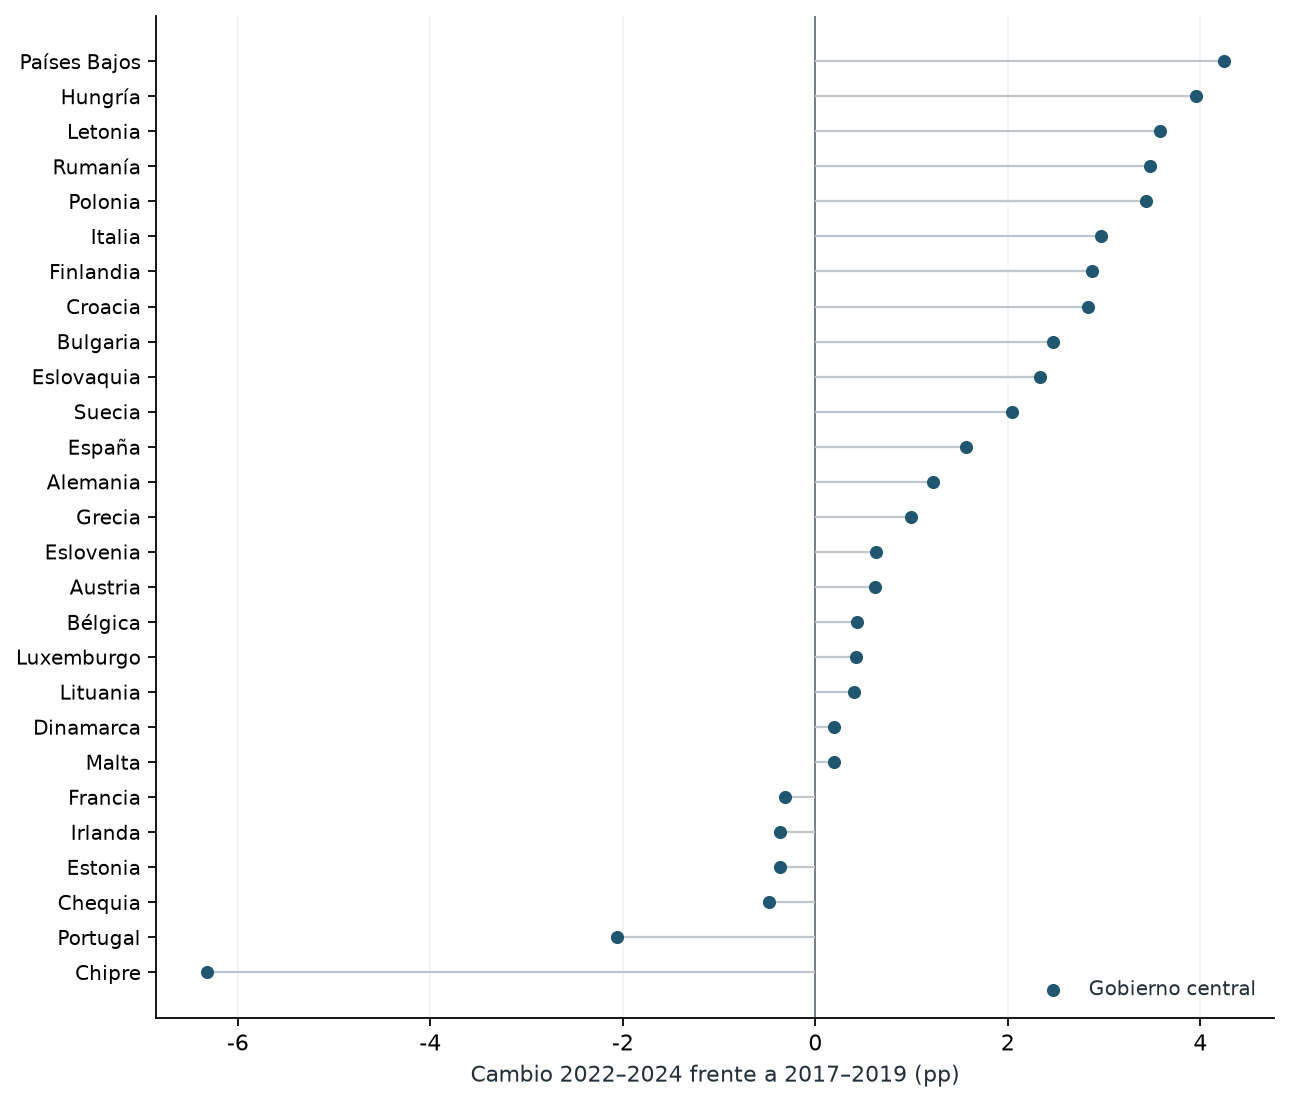

In [7]:
grouped = grouped_change(wide)
national = changes.join(grouped).rename(index=NAMES)
display(national.round(3))
print("Cambio agrupado medio:", grouped.mean().iloc[0])
print("Países con incremento agrupado:", int(grouped.iloc[:, 0].gt(0).sum()))
display(Image(filename=str(ROOT / ".resultados/figuras/comparacion_paises.png")))

## 7. Robustez
Las ventanas se conservan completas, incluidas las que reducen el efecto. La referencia precrisis no es un placebo causal y usa bienios no solapados. No hay dos trienios anteriores no solapados en 2015–2019. Se informa magnitud y dirección sin seleccionar por valores p.

In [8]:
sensitivity = temporal_sensitivity(wide)
display(sensitivity.round(3))

# Repetimos la media retirando un país cada vez, sin recalcular sus diferencias.
leave_one_out_results = []
for country in changes.index:
    remaining = changes.drop(country)
    row = {"excluded": country}
    for variable in share_columns:
        row[variable] = remaining[variable].mean()
    leave_one_out_results.append(row)

loo_df = pd.DataFrame(leave_one_out_results)
pd.testing.assert_frame_equal(loo_df, leave_one_out(changes), check_exact=True)
display(loo_df[share_columns].agg(["min", "max"]).round(3))
# El índice mide magnitud, no dirección; no se contrasta su media frente a cero.
assert "p_reallocation_index" not in loo_df.columns

,specification,pre,post,share_central,share_state,share_local,share_social_security,central_increases,mean_reallocation
0,Principal,2017–2019,2022–2024,1.148,-0.024,-0.456,-0.668,21,2.057
1,Base amplia,2015–2019,2022–2024,0.844,-0.019,-0.299,-0.526,17,2.010
2,Trienio inicial,2015–2017,2022–2024,0.602,-0.009,-0.129,-0.463,16,2.189
3,Bienios próximos,2018–2019,2022–2023,1.404,-0.038,-0.564,-0.802,24,2.207
4,Bienio reciente,2018–2019,2023–2024,1.095,-0.025,-0.480,-0.591,21,2.066
5,Extremos anuales,2019–2019,2024–2024,1.081,-0.022,-0.644,-0.415,22,1.994
6,Fase aguda,2017–2019,2020–2021,1.150,-0.060,-0.969,-0.122,23,2.077
7,Evolución posterior,2020–2021,2022–2024,-0.002,0.036,0.513,-0.547,10,1.222
8,Referencia precrisis,2015–2016,2018–2019,-0.820,0.022,0.490,0.308,3,1.590


,share_central,share_state,share_local,share_social_security
min,1.029,-0.025,-0.527,-0.949
max,1.436,-0.013,-0.335,-0.582


In [9]:
# Repetir en euros permite comprobar el efecto del redondeo en porcentaje del PIB.
wide_eur, _ = prepare(raw, "MIO_EUR")
changes_eur = calculate_changes(wide_eur)
unit_comparison = pd.DataFrame(
    {
        "PC_GDP": changes[share_columns].mean(),
        "MIO_EUR": changes_eur[share_columns].mean(),
    }
)
display(unit_comparison.round(6))

,PC_GDP,MIO_EUR
share_central,1.148329,1.147844
share_state,-0.023869,-0.024966
share_local,-0.456123,-0.445082
share_social_security,-0.668337,-0.677796


### Sensibilidad a la comparabilidad entre países
Se retiran los países señalados en las comprobaciones institucionales, uno a uno y en conjunto, y se comparan las medias.

In [10]:
quality_samples = {
    "Todos": [],
    "Sin Malta": ["MT"],
    "Sin Finlandia": ["FI"],
    "Sin Eslovaquia": ["SK"],
    "Sin Irlanda": ["IE"],
    "Sin FI, SK e IE": ["FI", "SK", "IE"],
}
quality_results = {}
for name, excluded in quality_samples.items():
    remaining = changes.drop(excluded)
    quality_results[name] = remaining[share_columns].mean()

display(pd.DataFrame(quality_results).T.round(3))

,share_central,share_state,share_local,share_social_security
Todos,1.148,-0.024,-0.456,-0.668
Sin Malta,1.185,-0.025,-0.466,-0.694
Sin Finlandia,1.082,-0.025,-0.465,-0.593
Sin Eslovaquia,1.103,-0.025,-0.466,-0.612
Sin Irlanda,1.207,-0.025,-0.521,-0.661
"Sin FI, SK e IE",1.090,-0.027,-0.546,-0.517


## 8. Conclusiones económicas
El mayor peso central es una regularidad descriptiva de la instantánea y de las ventanas examinadas. Su magnitud cambia al alterar la base temporal y al agrupar seguridad social. Es compatible con una mayor función financiera central, pero no identifica su mecanismo ni prueba pérdida de competencias territoriales.

Los periodos reducen la influencia de años aislados; no eliminan tendencias, shocks comunes, cambios de clasificación ni incertidumbre por revisiones. Las exclusiones por calidad son sensibilidades que cambian la población, no correcciones automáticas de las cuentas. La dependencia internacional limita la interpretación de la significación estadística.

**Implicación de economía pública:** evaluar centralización exige distinguir financiación, ejecución y decisión. Este trabajo documenta dónde se registra el gasto y ofrece una base para estudiar esas tres dimensiones sin confundirlas.

### Reproducción
Desde la raíz: `python reproducir.py`. Regenera datos, tablas, figuras y ejecuta ambos cuadernos. `python reproducir.py --pdf --package` compila el informe y crea el ZIP. Las versiones y huellas se guardan en `.resultados/verificacion.json`.